# 04 — Results analysis

Read the prioritizr outputs from `03` (`output_data/iter1_minshortfall30/`) and visualize
them. The notebook **adapts to the run type** recorded in `run_summary.json`:

- **proportion (LP) run** (current prototype) -> one continuous 0-1 allocation surface;
- **binary portfolio run** (later, with Gurobi) -> a suite of near-optimal alternatives.

Views: a **radar/star plot** (axes = 9 continuous features + 1 aggregated EFG axis;
representation per feature), the **allocation / selection-frequency map** over the Y2Y
boundary with PAs, the **solution map(s)**, and a **trade-off table**.

**Kernel:** select **`Python (y2y-geo)`** (the project `.venv`). Ethan runs the cells.

In [1]:
# ---- Setup --------------------------------------------------------------
import importlib, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rioxarray
import geopandas as gpd

import config
importlib.reload(config)
from config import (RESULTS_DIR, RESULTS_SUBDIR, MANIFEST_PATH, HANDOFF_DIR,
                    CORRIDOR_REF, TARGET_CRS, study_area)

RUN_DIR = RESULTS_DIR / RESULTS_SUBDIR
assert RUN_DIR.exists(), f"{RUN_DIR} not found -- run 03 first"
FIG_DIR = config.PROJECT_DIR / "figures"
FIG_DIR.mkdir(exist_ok=True)

manifest = json.loads(Path(MANIFEST_PATH).read_text())
summary = json.loads((RUN_DIR / "run_summary.json").read_text())
rep = pd.read_csv(RUN_DIR / "portfolio_representation.csv")

# eval_feature_representation_summary names the proportion column "relative_held";
# fall back to any "relative*" column if the prioritizr version differs.
REL = "relative_held" if "relative_held" in rep.columns else \
      next(c for c in rep.columns if c.startswith("relative"))

# Adapt to the run type recorded in the summary.
IS_PROP = summary["params"].get("decision_type") == "proportion"
RUN_KIND = "proportion / LP (continuous allocation)" if IS_PROP else "binary portfolio"

print(f"run: {summary['run_tag']} | objective: {summary['objective']} | {RUN_KIND}")
print(f"alternatives: {summary['n_alternatives']} | solve: {summary['solve_seconds']:.1f}s "
      f"| budget {summary['params']['budget_pct']:.0%}")

run: iter1_minshortfall30 | objective: min_shortfall | proportion / LP (continuous allocation)
alternatives: 1 | solve: 601.2s | budget 30%


In [2]:
# ---- Load portfolio + frequency rasters; validate grid ------------------
portfolio = rioxarray.open_rasterio(RUN_DIR / "portfolio.tif", masked=True)        # (band, y, x)
freq = rioxarray.open_rasterio(RUN_DIR / "selection_frequency.tif", masked=True).squeeze()

g = manifest["grid"]
# Prototype runs may be coarsened (config.PROTOTYPE_AGG_FACTOR), so the output grid can
# differ from the 1 km manifest grid -- require the two output rasters to align, and note
# if the resolution was coarsened.
assert portfolio.rio.width == freq.rio.width and portfolio.rio.height == freq.rio.height, \
    "portfolio and selection_frequency grids differ"
if (portfolio.rio.width, portfolio.rio.height) != (g["width"], g["height"]):
    print(f"note: prototype grid {portfolio.rio.width}x{portfolio.rio.height} "
          f"(coarsened from canonical {g['width']}x{g['height']})")
n_alt = portfolio.sizes["band"]
print(f"portfolio: {n_alt} solution(s) | grid {portfolio.rio.width} x {portfolio.rio.height}, "
      f"{portfolio.rio.crs}")
if IS_PROP:
    print(f"allocation surface: values {float(freq.min()):.2f}..{float(freq.max()):.2f} "
          f"(proportion of each cell selected)")
else:
    print(f"selection frequency: selected in {int(freq.min())}..{int(freq.max())} of {n_alt} alternatives")

note: prototype grid 643x1656 (coarsened from canonical 1286x3312)
portfolio: 1 solution(s) | grid 643 x 1656, ESRI:102008
allocation surface: values 0.00..1.00 (proportion of each cell selected)


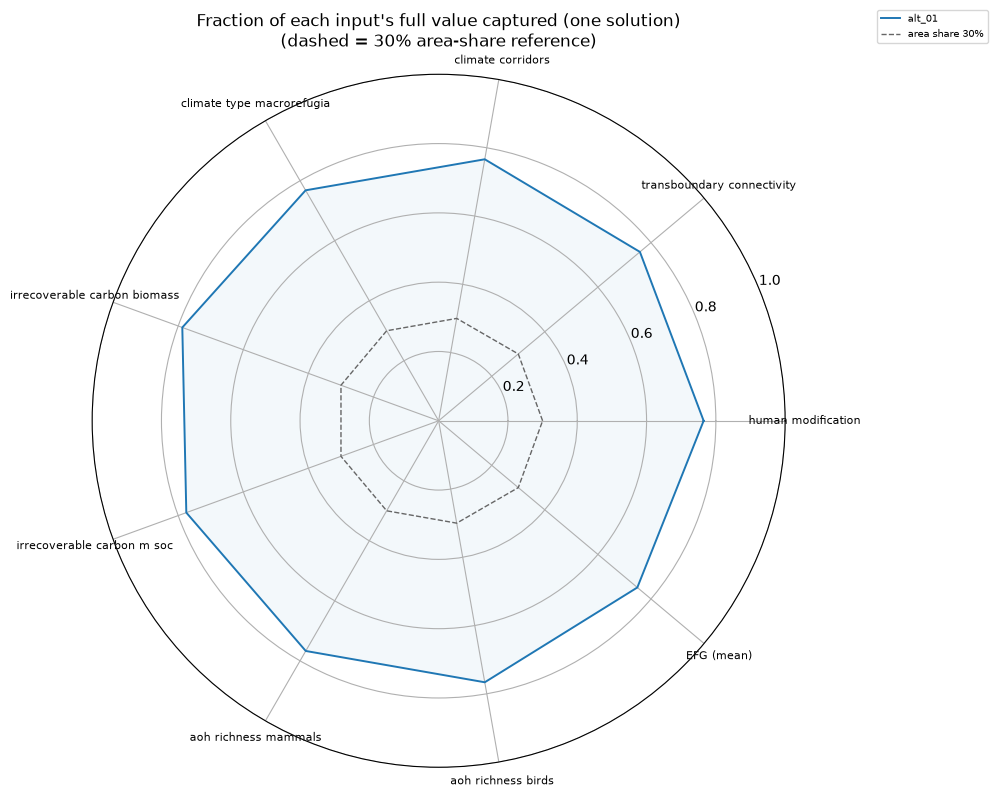

In [3]:
# ---- Radar / star plot: captured fraction per input --------------------
cont = [L["name"] for L in manifest["layers"] if L["role"] == "feature_continuous"]
efg  = [L["name"] for L in manifest["layers"] if L["role"] == "feature_efg"]
obj    = summary["objective"]
budget = summary["params"]["budget_pct"]
target = summary["params"]["target_pct"]

def profile(df):
    held = df.set_index("feature")[REL]
    vals = [float(held.get(n, np.nan)) for n in cont]   # one axis per continuous feature
    vals.append(float(held.reindex(efg).mean()))        # aggregated EFG axis (mean held)
    return vals

labels = [n.replace("_", " ") for n in cont] + ["EFG (mean)"]
ang = np.linspace(0, 2*np.pi, len(labels), endpoint=False).tolist()
ang += ang[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
for alt, df in rep.groupby("alternative"):
    v = profile(df); v += v[:1]
    ax.plot(ang, v, linewidth=1.4, label=alt)
    ax.fill(ang, v, alpha=0.05)
# 30% area-share reference: an input above this ring is captured better than its share of area.
ax.plot(ang, [budget]*len(ang), "--", color="0.4", linewidth=1, label=f"area share {budget:.0%}")
if obj == "min_set":
    ax.plot(ang, [target]*len(ang), ":", color="0.6", linewidth=1, label=f"target {target:.0%}")
ax.set_xticks(ang[:-1]); ax.set_xticklabels(labels, fontsize=8)
ax.set_ylim(0, max(1.0, float(rep[REL].max())))
if obj == "min_set":
    head = "Representation per feature (min-set)"
elif n_alt == 1:
    head = "Fraction of each input's full value captured (one solution)"
else:
    head = f"Captured fraction per input across {n_alt} alternatives"
ax.set_title(head + f"\n(dashed = {budget:.0%} area-share reference)", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.30, 1.10), fontsize=7)
fig.savefig(FIG_DIR / "radar_representation.png", dpi=150, bbox_inches="tight")
plt.show()

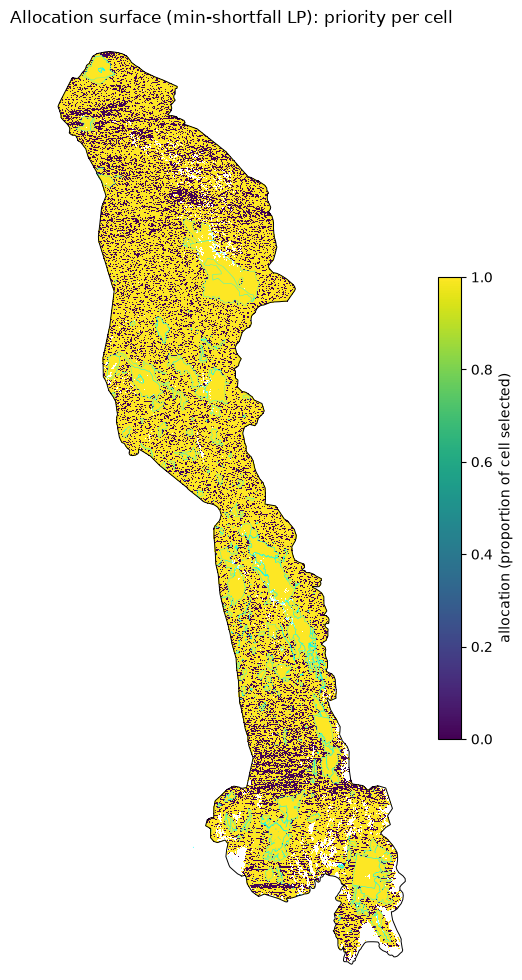

In [4]:
# ---- Allocation / selection-frequency map -------------------------------
boundary = gpd.read_file(CORRIDOR_REF).to_crs(TARGET_CRS)
pas = gpd.read_file(config.PA_VECTOR).to_crs(TARGET_CRS)

if IS_PROP:
    cmap, cbar_label = "viridis", "allocation (proportion of cell selected)"
    map_title = "Allocation surface (min-shortfall LP): priority per cell"
    out_png = "priority_allocation.png"
else:
    cmap, cbar_label = "magma", f"times selected (of {n_alt})"
    map_title = "Selection frequency: robust priorities across the near-optimal suite"
    out_png = "priority_selection_frequency.png"

fig, ax = plt.subplots(figsize=(7, 12))
freq.plot.imshow(ax=ax, cmap=cmap, add_colorbar=True,
                 cbar_kwargs=dict(label=cbar_label, shrink=0.5))
pas.boundary.plot(ax=ax, color="cyan", linewidth=0.3, alpha=0.7)
boundary.boundary.plot(ax=ax, color="black", linewidth=0.7)
ax.set_title(map_title); ax.set_aspect("equal"); ax.set_axis_off()
fig.savefig(FIG_DIR / out_png, dpi=150, bbox_inches="tight")
plt.show()

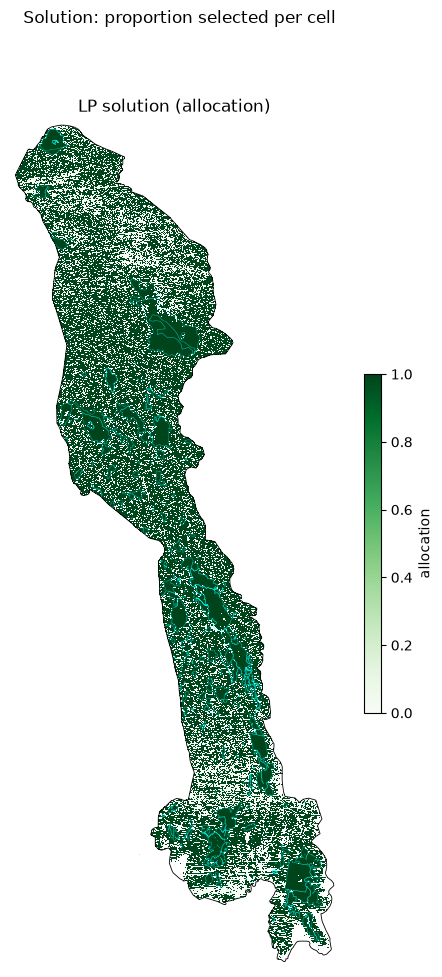

In [5]:
# ---- Solution map(s) ----------------------------------------------------
k = min(2, n_alt)
fig, axes = plt.subplots(1, k, figsize=(6.5*k, 11))
axes = np.atleast_1d(axes)
for i in range(k):
    a = axes[i]
    portfolio.isel(band=i).plot.imshow(ax=a, cmap="Greens", add_colorbar=IS_PROP,
                                       cbar_kwargs=dict(label="allocation", shrink=0.4) if IS_PROP else None)
    pas.boundary.plot(ax=a, color="cyan", linewidth=0.3, alpha=0.6)
    boundary.boundary.plot(ax=a, color="black", linewidth=0.6)
    panel = "LP solution (allocation)" if (IS_PROP and n_alt == 1) else f"alternative {i+1}"
    a.set_title(panel); a.set_aspect("equal"); a.set_axis_off()
fig.suptitle("Solution: proportion selected per cell" if (IS_PROP and n_alt == 1)
             else "Representative near-optimal alternatives (selected cells)")
fig.savefig(FIG_DIR / "solution_maps.png", dpi=150, bbox_inches="tight")
plt.show()

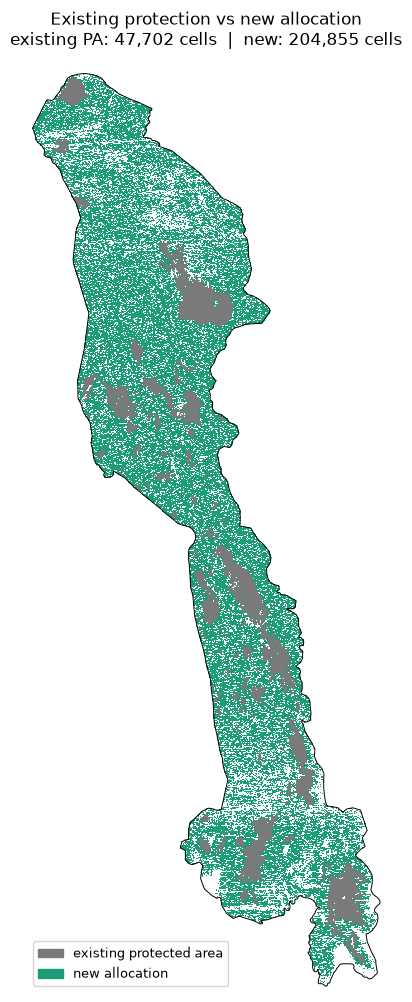

In [6]:
# ---- Existing protection vs new allocation ------------------------------
# Split selected cells into already-protected (locked-in PAs) vs newly allocated, so the
# additionality of the solution is visible. The PA mask is aligned to the solution grid
# (robust to coarsened prototype runs).
import xarray as xr
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

pa_grid = rioxarray.open_rasterio(HANDOFF_DIR / "mask_protected_areas.tif", masked=True).squeeze()
pa_on = pa_grid.rio.reproject_match(freq)          # nearest; align to (possibly coarse) grid
sol = portfolio.isel(band=0)
existing  = pa_on >= 0.5                            # locked-in protected areas
allocated = sol > 0.5                               # selected / allocated cells
new_alloc = allocated & ~existing
cat = xr.where(existing, 1, xr.where(new_alloc, 2, np.nan))

fig, ax = plt.subplots(figsize=(7, 12))
cat.plot.imshow(ax=ax, cmap=ListedColormap(["#7a7a7a", "#1b9e77"]),
                vmin=1, vmax=2, add_colorbar=False)
boundary.boundary.plot(ax=ax, color="black", linewidth=0.7)
ax.legend(handles=[Patch(color="#7a7a7a", label="existing protected area"),
                   Patch(color="#1b9e77", label="new allocation")],
          loc="lower left", fontsize=9, frameon=True)
n_exist = int(existing.sum()); n_new = int(new_alloc.sum())
ax.set_title(f"Existing protection vs new allocation\n"
             f"existing PA: {n_exist:,} cells  |  new: {n_new:,} cells")
ax.set_aspect("equal"); ax.set_axis_off()
fig.savefig(FIG_DIR / "existing_vs_new.png", dpi=150, bbox_inches="tight")
plt.show()

In [7]:
# ---- Trade-off table + headline stats -----------------------------------
stats = pd.DataFrame(summary["per_alternative"])
print("Per-solution summary:")
print(stats.to_string(index=False))
if IS_PROP:
    print("  (proportion run: n_selected = summed allocation = effective cells; "
          "n_added_beyond_pa = cells with any allocation outside PAs)")

n_pu = summary["n_planning_units"]; n_locked = summary["n_locked_in"]
print(f"\nregion planning units : {n_pu:,}")
print(f"area budget (cells)   : {summary['budget_cells']:,} ({summary['params']['budget_pct']:.0%})")
print(f"existing PAs locked in: {n_locked:,} ({100*n_locked/n_pu:.1f}% of region)")
if n_alt == 1:
    print(f"area selected         : {stats['pct_region'].iloc[0]:.1f}% of region")
    print(f"added beyond PAs      : {stats['n_added_beyond_pa'].iloc[0]:,.0f} cells")
else:
    print(f"mean area selected    : {stats['pct_region'].mean():.1f}% of region across {n_alt} alternatives")
    print(f"mean added beyond PAs : {stats['n_added_beyond_pa'].mean():,.0f} cells")

Per-solution summary:
alternative  n_selected  pct_region  n_added_beyond_pa
     alt_01      252406     76.3753             201697
  (proportion run: n_selected = summed allocation = effective cells; n_added_beyond_pa = cells with any allocation outside PAs)

region planning units : 330,481
area budget (cells)   : 99,144 (30%)
existing PAs locked in: 50,709 (15.3% of region)
area selected         : 76.4% of region
added beyond PAs      : 201,697 cells


## Clusters — candidate areas vs existing protection

Decompose the result into **two** sets of clusters, each profiled by its value mix (mean
5th–95th-scaled input value within it):
- **New candidate areas** = connected blocks of NEW allocation (selected, *outside* existing
  PAs) — where to expand protection, and what you'd gain.
- **Existing PA clusters** = connected blocks of current protected areas — what's already
  protected. Comparing the two profiles is a gap analysis (complementary vs redundant).

Requires clustering on (`config.BOUNDARY_PENALTY > 0`).

In [ ]:
# ---- Scaled feature stack + cluster NEW and EXISTING-PA blocks separately ----
from scipy import ndimage
from rasterio.enums import Resampling
importlib.reload(config)
MIN_CELLS, MAX_PLOTS = config.CLUSTER_MIN_CELLS, config.CLUSTER_MAX_PLOTS

sol0  = portfolio.isel(band=0)
sel   = sol0.fillna(0).values > 0.5                            # all selected (PA + new)
pa_on = (rioxarray.open_rasterio(HANDOFF_DIR / "mask_protected_areas.tif", masked=True)
         .squeeze().rio.reproject_match(sol0).values >= 0.5)   # existing PAs on the solution grid
new_mask = sel & ~pa_on                                        # NEW allocation only
rx, ry = sol0.rio.resolution(); cell_km2 = abs(rx * ry) / 1e6

cont_layers = [L for L in manifest["layers"] if L["role"] == "feature_continuous"]
efg_layers  = [L for L in manifest["layers"] if L["role"] == "feature_efg"]
axes_labels = [L["name"].replace("_", " ") for L in cont_layers] + ["EFG (mean)"]

def scaled(path):                                              # feature -> [0,1] over PUs (5th-95th)
    r = rioxarray.open_rasterio(config.PROJECT_DIR / path, masked=True).squeeze()
    r = r.rio.reproject_match(sol0, resampling=Resampling.average)
    a = r.values.astype("float32")
    lo, hi = np.nanpercentile(a, 5), np.nanpercentile(a, 95)
    return np.clip((a - lo) / (hi - lo if hi > lo else 1.0), 0, 1)

cont_stack = np.stack([scaled(L["path"]) for L in cont_layers])
efg_stack  = np.stack([scaled(L["path"]) for L in efg_layers])

def cluster_profile(mask, kind):
    lab, n = ndimage.label(mask, structure=np.ones((3, 3), int))   # 8-connectivity
    cnt = np.bincount(lab.ravel())
    ids = [i for i in range(1, n + 1) if cnt[i] >= MIN_CELLS]
    ids = sorted(ids, key=lambda i: -cnt[i])[:MAX_PLOTS]
    profs, stats = {}, []
    for cid in ids:
        m = lab == cid
        prof = [float(np.nanmean(cont_stack[k][m])) for k in range(len(cont_layers))]
        prof.append(float(np.nanmean(efg_stack[:, m])))
        profs[cid] = prof
        top3 = ", ".join(np.array(axes_labels)[np.argsort(prof)[::-1][:3]])
        stats.append({"cluster": cid, "cells": int(cnt[cid]),
                      "area_km2": int(round(cnt[cid] * cell_km2)), "top_inputs": top3})
    print(f"{kind:22s}: {n} components, {len(ids)} kept (>= {MIN_CELLS} cells)")
    return dict(lab=lab, ids=ids, cnt=cnt, profs=profs, stats=stats)

def plot_clusters(C, title, fname, color):
    ids = C["ids"]
    if not ids:
        print(f"{title}: no clusters >= {MIN_CELLS} cells"); return
    ang = np.linspace(0, 2*np.pi, len(axes_labels), endpoint=False).tolist(); ang += ang[:1]
    short = [l.replace("irrecoverable carbon ", "C:").replace("transboundary ", "")
              .replace("aoh richness ", "").replace("climate ", "") for l in axes_labels]
    ncol = min(4, len(ids)); nrow = int(np.ceil(len(ids) / ncol))
    fig, axx = plt.subplots(nrow, ncol, figsize=(3.6*ncol, 3.6*nrow), subplot_kw=dict(polar=True))
    axx = np.atleast_1d(axx).ravel()
    for ax, cid in zip(axx, ids):
        v = C["profs"][cid] + C["profs"][cid][:1]
        ax.plot(ang, v, color=color, linewidth=1.3); ax.fill(ang, v, color=color, alpha=0.25)
        ax.set_xticks(ang[:-1]); ax.set_xticklabels(short, fontsize=5)
        ax.set_ylim(0, 1); ax.set_yticklabels([])
        ax.set_title(f"cluster {cid}  ({int(C['cnt'][cid])} cells)", fontsize=8)
    for ax in axx[len(ids):]: ax.set_visible(False)
    fig.suptitle(title, y=1.005); fig.tight_layout()
    fig.savefig(FIG_DIR / fname, dpi=150, bbox_inches="tight"); plt.show()
    print(pd.DataFrame(C["stats"]).to_string(index=False))

NEW = cluster_profile(new_mask, "new candidate areas")
PA  = cluster_profile(pa_on,    "existing PA clusters")
print(f"cell size {cell_km2:.1f} km^2")

In [ ]:
# ---- Map: new candidate areas (colored, numbered) over existing PAs (grey) ----
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(8, 12))
sol0.copy(data=np.where(np.isin(PA["lab"], PA["ids"]), 1.0, np.nan).astype("float32")) \
    .plot.imshow(ax=ax, cmap=ListedColormap(["0.6"]), add_colorbar=False)
if NEW["ids"]:
    sol0.copy(data=np.where(np.isin(NEW["lab"], NEW["ids"]), NEW["lab"], np.nan).astype("float32")) \
        .plot.imshow(ax=ax, cmap="tab20", add_colorbar=False)
    for cid in NEW["ids"]:
        cy, cx = ndimage.center_of_mass(NEW["lab"] == cid)
        ax.text(float(sol0.x.values[int(round(cx))]), float(sol0.y.values[int(round(cy))]), str(cid),
                fontsize=8, fontweight="bold", ha="center", va="center",
                bbox=dict(boxstyle="circle", fc="white", ec="black", alpha=0.8))
boundary.boundary.plot(ax=ax, color="black", linewidth=0.7)
ax.legend(handles=[Patch(color="0.6", label="existing PA"),
                   Patch(color="#1f77b4", label="new candidate area (numbered)")],
          loc="lower left", fontsize=9)
ax.set_title("New candidate areas vs existing protection")
ax.set_aspect("equal"); ax.set_axis_off()
fig.savefig(FIG_DIR / "clusters_map.png", dpi=150, bbox_inches="tight"); plt.show()

In [ ]:
# ---- New candidate areas: value-profile star plots + table ---------------
plot_clusters(NEW, "New candidate areas — value profiles", "clusters_new.png", "#1b9e77")

In [ ]:
# ---- Map: existing PA clusters (colored, numbered) -----------------------
fig, ax = plt.subplots(figsize=(8, 12))
if PA["ids"]:
    sol0.copy(data=np.where(np.isin(PA["lab"], PA["ids"]), PA["lab"], np.nan).astype("float32")) \
        .plot.imshow(ax=ax, cmap="tab20", add_colorbar=False)
    for cid in PA["ids"]:
        cy, cx = ndimage.center_of_mass(PA["lab"] == cid)
        ax.text(float(sol0.x.values[int(round(cx))]), float(sol0.y.values[int(round(cy))]), str(cid),
                fontsize=8, fontweight="bold", ha="center", va="center",
                bbox=dict(boxstyle="circle", fc="white", ec="black", alpha=0.8))
boundary.boundary.plot(ax=ax, color="black", linewidth=0.7)
ax.set_title(f"Existing PA clusters — {len(PA['ids'])} largest, numbered")
ax.set_aspect("equal"); ax.set_axis_off()
fig.savefig(FIG_DIR / "clusters_pa_map.png", dpi=150, bbox_inches="tight"); plt.show()

In [ ]:
# ---- Existing PA clusters: value-profile star plots + table --------------
plot_clusters(PA, "Existing PA clusters — value profiles", "clusters_pa.png", "#7570b3")